# MWE 16 - `Kabs` benchmark: constant viscosity vs pressure-dependent viscosity

This notebook quantifies how much the apparent permeability estimate changes when
the fluid viscosity is treated as:
- a spatially constant scalar equal to the midpoint viscosity across the imposed pressure range
- a pressure-dependent thermodynamic model tabulated over the boundary-pressure interval

Scientific scope:
- geometry is kept fixed so the observed differences are attributable to `mu(P)` only
- the constant-viscosity baseline is intentionally matched to the midpoint thermodynamic viscosity
- the reported `Kabs` therefore isolates the impact of the spatial viscosity field on the solved flow
  rate, not a change in the reporting convention

In [8]:
from __future__ import annotations

import sys
from pathlib import Path
from time import perf_counter

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voids.examples import make_cartesian_mesh_network
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.physics.thermo import TabulatedWaterViscosityModel

plt.style.use("seaborn-v0_8-whitegrid")

In [9]:
def find_notebooks_base() -> Path:
    """Return the notebook root used for saved figures and CSV artifacts."""

    from os import environ

    if "VOIDS_NOTEBOOKS_PATH" in environ:
        return Path(environ["VOIDS_NOTEBOOKS_PATH"]).expanduser().resolve()

    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "notebooks").is_dir() and (
            candidate / "jupytext.toml"
        ).exists():
            return candidate / "notebooks"
    return cwd


BACKEND = "thermo"
TEMPERATURE_K = 298.15
CONDUCTANCE_MODEL = "valvatne_blunt"
PRESSURE_CASES = {
    "mild_gradient": {"pin": 5.5e6, "pout": 5.0e6},
    "moderate_gradient": {"pin": 8.0e6, "pout": 5.0e6},
    "strong_gradient": {"pin": 1.5e7, "pout": 5.0e6},
}
NETWORK_CASES = [
    {
        "case": "mesh_20x20_tight",
        "shape": (20, 20),
        "pore_radius": 0.18,
        "throat_radius": 0.07,
    },
    {
        "case": "mesh_25x25_medium",
        "shape": (25, 25),
        "pore_radius": 0.22,
        "throat_radius": 0.09,
    },
    {
        "case": "mesh_30x30_open",
        "shape": (30, 30),
        "pore_radius": 0.26,
        "throat_radius": 0.11,
    },
]
model = TabulatedWaterViscosityModel.from_backend(
    BACKEND,
    temperature=TEMPERATURE_K,
    pressure_points=192,
)
constant_options = SinglePhaseOptions(
    conductance_model=CONDUCTANCE_MODEL,
    solver="direct",
)
variable_options = SinglePhaseOptions(
    conductance_model=CONDUCTANCE_MODEL,
    solver="direct",
    nonlinear_solver="newton",
    nonlinear_pressure_tolerance=1.0e-10,
)
NOTEBOOKS_BASE = find_notebooks_base()
OUTPUT_DIR = NOTEBOOKS_BASE / "outputs" / "16_mwe_viscosity_model_kabs_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
def build_mesh_case(
    shape: tuple[int, int], *, pore_radius: float, throat_radius: float
):
    """Build one synthetic mesh case used in the benchmark."""

    return make_cartesian_mesh_network(
        shape,
        spacing=1.0,
        thickness=1.0,
        pore_radius=pore_radius,
        throat_radius=throat_radius,
    )


def finalize_figure(fig) -> None:
    """Show figures in notebooks and close them in non-interactive script runs."""

    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        plt.close(fig)
    else:
        plt.show()


def summarize_axis_profile(result, net) -> pd.DataFrame:
    """Return x-wise mean pressure and viscosity profiles for one solve."""

    frame = pd.DataFrame(
        {
            "x": np.asarray(net.pore_coords[:, 0], dtype=float),
            "pressure": np.asarray(result.pore_pressure, dtype=float),
            "viscosity": np.asarray(result.pore_viscosity, dtype=float),
        }
    )
    profile = (
        frame.groupby("x", as_index=False)
        .agg(
            pressure_mean=("pressure", "mean"),
            pressure_min=("pressure", "min"),
            pressure_max=("pressure", "max"),
            viscosity_mean=("viscosity", "mean"),
            viscosity_min=("viscosity", "min"),
            viscosity_max=("viscosity", "max"),
        )
        .sort_values("x")
    )
    return profile


def run_case(
    net,
    *,
    pressure_case: dict[str, float],
) -> dict[str, float]:
    """Run constant and variable-viscosity solves for one network/pressure pair."""

    pin = float(pressure_case["pin"])
    pout = float(pressure_case["pout"])
    mu_ref = model.reference_viscosity(pin=pin, pout=pout)
    bc = PressureBC("inlet_xmin", "outlet_xmax", pin=pin, pout=pout)

    tic = perf_counter()
    constant_result = solve(
        net,
        fluid=FluidSinglePhase(viscosity=mu_ref),
        bc=bc,
        axis="x",
        options=constant_options,
    )
    constant_seconds = perf_counter() - tic

    tic = perf_counter()
    variable_result = solve(
        net,
        fluid=FluidSinglePhase(viscosity_model=model),
        bc=bc,
        axis="x",
        options=variable_options,
    )
    variable_seconds = perf_counter() - tic

    return {
        "mu_ref": mu_ref,
        "constant_result": constant_result,
        "variable_result": variable_result,
        "constant_Q": constant_result.total_flow_rate,
        "variable_Q": variable_result.total_flow_rate,
        "constant_kabs": constant_result.permeability["x"],
        "variable_kabs": variable_result.permeability["x"],
        "constant_seconds": constant_seconds,
        "variable_seconds": variable_seconds,
        "newton_iterations": float(variable_result.solver_info["nonlinear_iterations"]),
        "k_ratio_variable_to_constant": variable_result.permeability["x"]
        / constant_result.permeability["x"],
        "q_ratio_variable_to_constant": variable_result.total_flow_rate
        / constant_result.total_flow_rate,
    }

## Benchmark design

Why this setup is scientifically useful:
- the same network is solved twice, so geometry and boundary labels are identical
- the constant-viscosity baseline is calibrated to the midpoint thermodynamic viscosity
- the reported `Kabs` shift therefore measures the transport consequence of a spatial viscosity field
- the pressure windows use absolute pressures in the MPa range so the thermo backend remains in a
  physically sensible liquid-water regime

The saved outputs from this notebook are written to:

`notebooks/outputs/16_mwe_viscosity_model_kabs_benchmark/`

In [11]:
pressure_design_df = pd.DataFrame(
    [
        {
            "pressure_case": name,
            "pin_MPa": values["pin"] / 1.0e6,
            "pout_MPa": values["pout"] / 1.0e6,
            "delta_p_MPa": (values["pin"] - values["pout"]) / 1.0e6,
            "mu_midpoint_mPa_s": 1.0e3
            * model.reference_viscosity(
                pin=values["pin"],
                pout=values["pout"],
            ),
        }
        for name, values in PRESSURE_CASES.items()
    ]
)
pressure_design_df

,pressure_case,pin_MPa,pout_MPa,delta_p_MPa,mu_midpoint_mPa_s
0,mild_gradient,5.5,5.0,0.5,0.889349
1,moderate_gradient,8.0,5.0,3.0,0.889199
2,strong_gradient,15.0,5.0,10.0,0.888807


## Thermodynamic viscosity curves over the benchmark windows

This figure is important for interpretation: if the viscosity is nearly flat over the full pressure
interval, then any `Kabs` difference should also be small. If the curve is strongly sloped, a larger
divergence between constant and variable viscosity is expected.

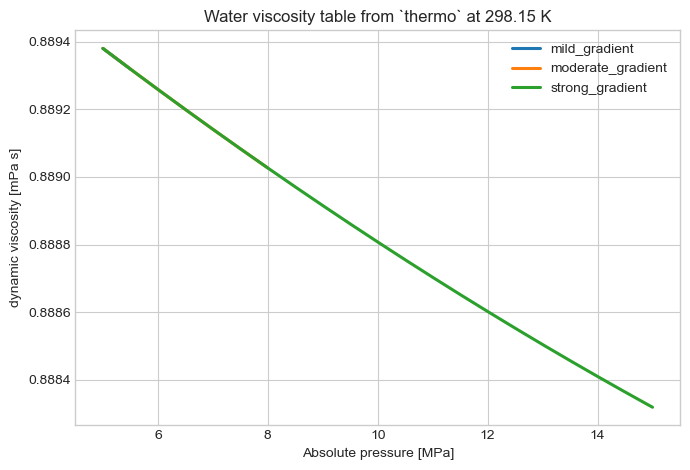

In [12]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))
for pressure_name, pressure_case in PRESSURE_CASES.items():
    p = np.linspace(pressure_case["pout"], pressure_case["pin"], 200)
    mu = model.evaluate(p, pin=pressure_case["pin"], pout=pressure_case["pout"])
    ax.plot(
        p / 1.0e6,
        1.0e3 * mu,
        linewidth=2.2,
        label=pressure_name,
    )
ax.set_title(f"Water viscosity table from `{BACKEND}` at {TEMPERATURE_K:.2f} K")
ax.set_xlabel("Absolute pressure [MPa]")
ax.set_ylabel("dynamic viscosity [mPa s]")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "thermo_viscosity_curves.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Benchmark matrix

The pressure windows are expressed in absolute Pa because the thermodynamic viscosity model requires
absolute pressure. The constant-viscosity baseline uses the same midpoint reference viscosity that
the variable-viscosity run uses for permeability reporting.

In [13]:
rows: list[dict[str, float | str | tuple[int, int]]] = []
representative_artifacts: dict[str, object] = {}
for network_case in NETWORK_CASES:
    net = build_mesh_case(
        network_case["shape"],
        pore_radius=float(network_case["pore_radius"]),
        throat_radius=float(network_case["throat_radius"]),
    )
    for pressure_name, pressure_case in PRESSURE_CASES.items():
        metrics = run_case(net, pressure_case=pressure_case)
        rows.append(
            {
                **network_case,
                "pressure_case": pressure_name,
                "pin": pressure_case["pin"],
                "pout": pressure_case["pout"],
                **metrics,
            }
        )
        if (
            network_case["case"] == "mesh_25x25_medium"
            and pressure_name == "moderate_gradient"
        ):
            representative_artifacts = {
                "network": net,
                "constant_result": metrics["constant_result"],
                "variable_result": metrics["variable_result"],
                "pressure_case": pressure_case,
            }

summary_df = pd.DataFrame(rows)
summary_df = summary_df.drop(columns=["constant_result", "variable_result"])
summary_df[
    [
        "case",
        "pressure_case",
        "pin",
        "pout",
        "mu_ref",
        "constant_kabs",
        "variable_kabs",
        "k_ratio_variable_to_constant",
        "q_ratio_variable_to_constant",
        "newton_iterations",
    ]
]

summary_df.to_csv(OUTPUT_DIR / "kabs_viscosity_benchmark.csv", index=False)

## `Kabs` ratio summary

A ratio close to one means the midpoint-constant viscosity already captures the transport response
well for that pressure window. Larger deviations indicate that the spatial variation of `mu(P)` is
materially changing the resolved flow field.

In [14]:
ratio_pivot = summary_df.pivot(
    index="pressure_case",
    columns="case",
    values="k_ratio_variable_to_constant",
)
ratio_pivot

case,mesh_20x20_tight,mesh_25x25_medium,mesh_30x30_open
pressure_case,,,
mild_gradient,1.000000,1.000000,1.000000
moderate_gradient,0.999999,0.999999,0.999999
strong_gradient,0.999984,0.999984,0.999984


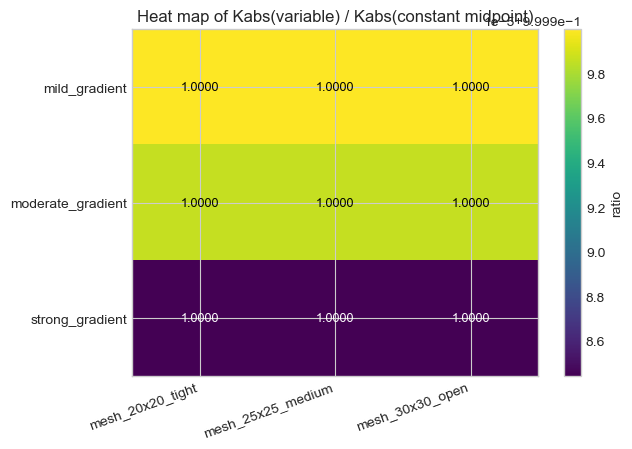

In [15]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
image = ax.imshow(ratio_pivot.to_numpy(dtype=float), cmap="viridis", aspect="auto")
ax.set_xticks(np.arange(ratio_pivot.shape[1]))
ax.set_xticklabels(ratio_pivot.columns, rotation=20, ha="right")
ax.set_yticks(np.arange(ratio_pivot.shape[0]))
ax.set_yticklabels(ratio_pivot.index)
ax.set_title("Heat map of Kabs(variable) / Kabs(constant midpoint)")
for i in range(ratio_pivot.shape[0]):
    for j in range(ratio_pivot.shape[1]):
        ax.text(
            j,
            i,
            f"{ratio_pivot.iloc[i, j]:.4f}",
            ha="center",
            va="center",
            color=(
                "white"
                if ratio_pivot.iloc[i, j] < ratio_pivot.to_numpy().mean()
                else "black"
            ),
            fontsize=9,
        )
fig.colorbar(image, ax=ax, label="ratio")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kabs_ratio_heatmap.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

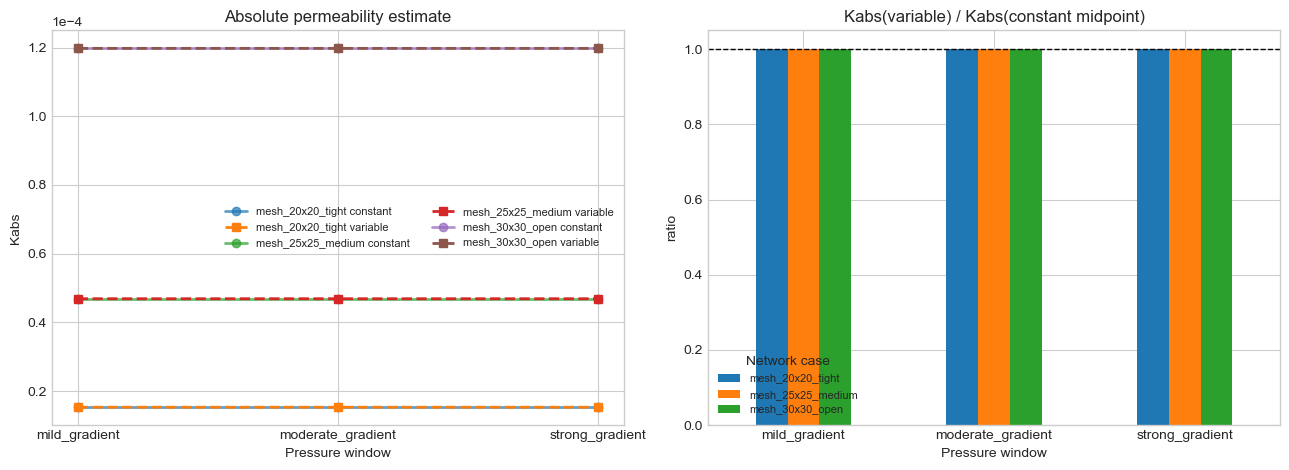

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for case_name, group in summary_df.groupby("case", sort=False):
    axes[0].plot(
        group["pressure_case"],
        group["constant_kabs"],
        marker="o",
        linewidth=2,
        label=f"{case_name} constant",
        alpha=0.7,
    )
    axes[0].plot(
        group["pressure_case"],
        group["variable_kabs"],
        marker="s",
        linewidth=2,
        linestyle="--",
        label=f"{case_name} variable",
    )

axes[0].set_title("Absolute permeability estimate")
axes[0].set_xlabel("Pressure window")
axes[0].set_ylabel("Kabs")
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[0].legend(fontsize=8, ncol=2)

ratio_pivot.plot(kind="bar", ax=axes[1], rot=0)
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1.0)
axes[1].set_title("Kabs(variable) / Kabs(constant midpoint)")
axes[1].set_xlabel("Pressure window")
axes[1].set_ylabel("ratio")
axes[1].legend(title="Network case", fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kabs_comparison.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Representative pressure and viscosity profiles

The next figure shows one moderate case in more detail. The pressure field should remain nearly
linear along the mean flow axis, while the viscosity profile reflects the imposed absolute-pressure
dependence. This plot makes the mechanism behind the `Kabs` shift visible.

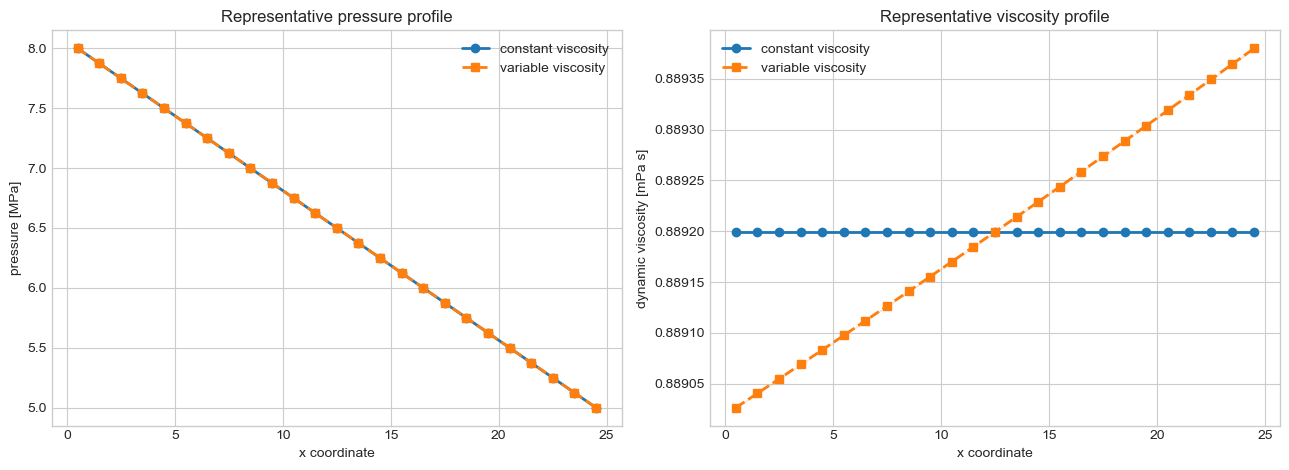

In [17]:
rep_net = representative_artifacts["network"]
rep_constant = representative_artifacts["constant_result"]
rep_variable = representative_artifacts["variable_result"]
constant_profile = summarize_axis_profile(rep_constant, rep_net)
variable_profile = summarize_axis_profile(rep_variable, rep_net)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    constant_profile["x"],
    constant_profile["pressure_mean"] / 1.0e6,
    marker="o",
    linewidth=2,
    label="constant viscosity",
)
axes[0].plot(
    variable_profile["x"],
    variable_profile["pressure_mean"] / 1.0e6,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="variable viscosity",
)
axes[0].fill_between(
    variable_profile["x"],
    variable_profile["pressure_min"] / 1.0e6,
    variable_profile["pressure_max"] / 1.0e6,
    alpha=0.18,
    color="tab:orange",
)
axes[0].set_title("Representative pressure profile")
axes[0].set_xlabel("x coordinate")
axes[0].set_ylabel("pressure [MPa]")
axes[0].legend()

axes[1].plot(
    constant_profile["x"],
    1.0e3 * constant_profile["viscosity_mean"],
    marker="o",
    linewidth=2,
    label="constant viscosity",
)
axes[1].plot(
    variable_profile["x"],
    1.0e3 * variable_profile["viscosity_mean"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="variable viscosity",
)
axes[1].fill_between(
    variable_profile["x"],
    1.0e3 * variable_profile["viscosity_min"],
    1.0e3 * variable_profile["viscosity_max"],
    alpha=0.18,
    color="tab:orange",
)
axes[1].set_title("Representative viscosity profile")
axes[1].set_xlabel("x coordinate")
axes[1].set_ylabel("dynamic viscosity [mPa s]")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "representative_profiles.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Runtime context

The variable-viscosity solve is more expensive because it solves a nonlinear problem. The table below
separates the physics effect (`Kabs` ratio) from the added wall-clock cost.

In [ ]:
runtime_df = summary_df[
    [
        "case",
        "pressure_case",
        "constant_seconds",
        "variable_seconds",
        "newton_iterations",
    ]
].copy()
runtime_df["runtime_ratio_variable_to_constant"] = (
    runtime_df["variable_seconds"] / runtime_df["constant_seconds"]
)

runtime_df.to_csv(OUTPUT_DIR / "runtime_summary.csv", index=False)

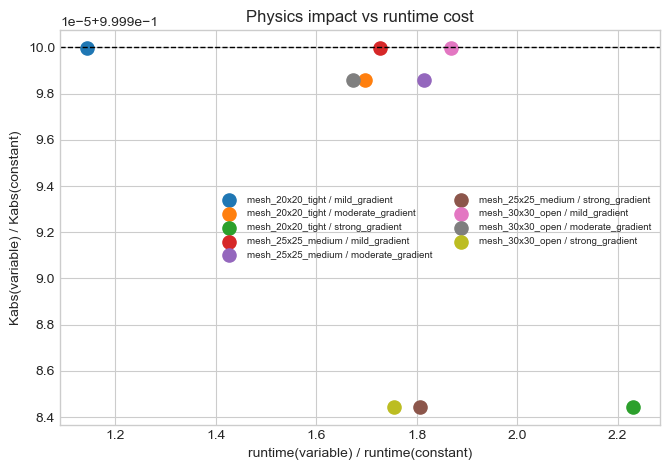

In [19]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))
merged_tradeoff_df = summary_df.merge(
    runtime_df[
        [
            "case",
            "pressure_case",
            "runtime_ratio_variable_to_constant",
        ]
    ],
    on=["case", "pressure_case"],
    how="left",
)
for row in merged_tradeoff_df.itertuples(index=False):
    ax.scatter(
        row.runtime_ratio_variable_to_constant,
        row.k_ratio_variable_to_constant,
        s=90,
        label=f"{row.case} / {row.pressure_case}",
    )
ax.axhline(1.0, color="k", linestyle="--", linewidth=1.0)
ax.set_title("Physics impact vs runtime cost")
ax.set_xlabel("runtime(variable) / runtime(constant)")
ax.set_ylabel("Kabs(variable) / Kabs(constant)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "runtime_vs_kabs_tradeoff.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Interpretation

Use this notebook to answer:
- whether a constant midpoint viscosity is already sufficient for your operating pressure window
- how large the induced `Kabs` shift is when `mu(P)` is resolved explicitly
- whether the extra nonlinear solve cost is justified by the size of that `Kabs` shift

If the ratio remains near one across the relevant pressure range, using constant viscosity is still a
defensible simplification for that regime.

Recommended reading of the figures:
- start with the viscosity curves to check whether the constitutive variation is actually strong
- then inspect the heat map and `Kabs` curves to see if that constitutive variation translates into a
  meaningful permeability shift
- finally use the runtime tradeoff plot to decide whether the nonlinear solve cost is justified for
  the operating regime of interest